# Feature Audit: Redundancy, Collinearity, and Data Integrity

This notebook audits the final feature table before model training.

**Objectives**
- quantify missingness and identify unstable variables,
- detect multicollinearity (Pearson blocks and VIF),
- assess feature-target interactions,
- produce a reproducible candidate list: `FEATURES_TO_DROP`.

The analysis is aligned with a leakage-aware training design (purged
walk-forward CV), where feature quality and temporal validity are audited
before model fitting.


## Methodological Rationale (Thesis Context)

In non-stationary energy markets, a large feature space can degrade model
robustness through redundancy, unstable covariance structures, and hidden
data quality issues. The present audit combines:

1. **Missing-value diagnostics** to detect structurally weak inputs.
2. **Pearson correlation + clustering** to identify redundant blocks.
3. **Variance Inflation Factor (VIF)** to quantify multicollinearity risk.
4. **Target interaction checks** to detect dead features and leakage-like
   patterns.

This workflow does not replace causal validation, but it improves feature-space
conditioning before purged time-series cross-validation.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')
sns.set_context('paper', font_scale=1.1)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)


In [2]:
# Load final feature table (Polars first for speed)
feature_path = Path('../data/features/all_data_features.parquet')
if not feature_path.exists():
    raise FileNotFoundError(f'Expected feature file not found: {feature_path}')

pl_df = pl.read_parquet(feature_path)
print(f'Loaded: {feature_path}')
print(f'Shape (rows, cols): {pl_df.height:,}, {pl_df.width}')

# Convert to pandas for analytics stack
pdf = pl_df.to_pandas()
if 'timestamp_utc' in pdf.columns:
    pdf['timestamp_utc'] = pd.to_datetime(pdf['timestamp_utc'], utc=True, errors='coerce')
    pdf = pdf.sort_values('timestamp_utc').reset_index(drop=True)

pdf.head(3)


Loaded: ../data/features/all_data_features.parquet
Shape (rows, cols): 879, 338


,da_price_AT,da_price_BE,da_price_CH,da_price_CZ,da_price_DK1,da_price_DK2,da_price_FR,da_price_NL,da_price_PL,da_price_SE4,load_actual_entsoe,load_forecast_da_entsoe,wind_onshore_actual_entsoe,wind_offshore_actual_entsoe,solar_actual_entsoe,biomass_actual_entsoe,hydro_reservoir_actual_entsoe,hydro_pumped_actual_entsoe,hydro_ror_actual_entsoe,wind_onshore_forecast_da_entsoe,wind_offshore_forecast_da_entsoe,solar_forecast_da_entsoe,wind_onshore_forecast_id_entsoe,wind_offshore_forecast_id_entsoe,solar_forecast_id_entsoe,NRV_balance,reBAP_shortage_surplus,afrr_activated_mw_pos,afrr_activated_mw_neg,mfrr_activated_mw_pos,mfrr_activated_mw_neg,afrr_picasso_mw_pos,afrr_picasso_mw_neg,afrr_picasso_net_mw,mfrr_mari_net_mw,NRV_balance_source,NRV_balance_source_is_fallback,rz_saldo_mw_source,rz_saldo_mw_source_is_fallback,afrr_capacity_offered_mw_neg,afrr_capacity_offered_mw_pos,afrr_capacity_price_neg,afrr_capacity_price_pos,net_import_export_mw,afrr_marginal_activation_price_neg,afrr_marginal_activation_price_pos,afrr_activation_offered_mw_neg,afrr_activation_offered_mw_pos,afrr_bid_avg_activation_price_neg,afrr_bid_avg_activation_price_pos,afrr_bid_vwap_activation_price_neg,afrr_bid_vwap_activation_price_pos,bid_alloc_mw_neg,bid_alloc_mw_pos,afrr_activated_mw_pos_regelleistung,afrr_activated_mw_neg_regelleistung,afrr_vwap_pos,afrr_vwap_neg,generation_fossil_brown_coal_mw,generation_fossil_hard_coal_mw,generation_fossil_gas_mw,generation_nuclear_mw,generation_hydro_pumped_storage_mw,da_price_eur,price_intraday_eur,wind_forecast_de,system_stress_signal,wind_onshore_capacity,wind_offshore_capacity,solar_capacity,gas_capacity,hard_coal_capacity,lignite_capacity,pumped_storage_capacity,gas_price_ttf,coal_price_api2,co2_price_eua,timestamp_utc,is_local_reconstruction_only,awarded_capacity_mw_pos,awarded_capacity_mw_neg,bid_signed_vwap_eur_mwh_pos,bid_signed_vwap_eur_mwh_neg,afrr_capacity_awarded_mw_pos,afrr_capacity_awarded_mw_neg,wind_total_error_da,solar_error_da,wind_forecast_update,residual_load_calc,afrr_picasso_churn_mw,simulated_afrr_profit_eur,activation_rate_phys_pos,activation_rate_phys_neg,activation_rate_ml_pos,activation_rate_ml_neg,afrr_activation_rate_pos,afrr_activation_rate_neg,is_picasso_active,da_price_eur_slog1p,price_intraday_eur_slog1p,...,target_pos_h23,target_neg_h23,target_pos_h24,target_neg_h24,target_pos_h25,target_neg_h25,target_pos_h26,target_neg_h26,target_pos_h27,target_neg_h27,target_pos_h28,target_neg_h28,target_pos_h29,target_neg_h29,target_pos_h30,target_neg_h30,target_pos_h31,target_neg_h31,target_pos_h32,target_neg_h32,target_pos_h33,target_neg_h33,target_pos_h34,target_neg_h34,target_pos_h35,target_neg_h35,target_pos_h36,target_neg_h36,target_pos_h37,target_neg_h37,target_pos_h38,target_neg_h38,target_pos_h39,target_neg_h39,target_pos_h40,target_neg_h40,target_pos_h41,target_neg_h41,target_pos_h42,target_neg_h42,target_pos_h43,target_neg_h43,target_pos_h44,target_neg_h44,target_pos_h45,target_neg_h45,target_pos_h46,target_neg_h46,target_pos_h47,target_neg_h47,target_pos_h48,target_neg_h48,target_pos_h49,target_neg_h49,target_pos_h50,target_neg_h50,target_pos_h51,target_neg_h51,target_pos_h52,target_neg_h52,target_pos_h53,target_neg_h53,target_pos_h54,target_neg_h54,target_pos_h55,target_neg_h55,target_pos_h56,target_neg_h56,target_pos_h57,target_neg_h57,target_pos_h58,target_neg_h58,target_pos_h59,target_neg_h59,target_pos_h60,target_neg_h60,target_pos_h61,target_neg_h61,target_pos_h62,target_neg_h62,target_pos_h63,target_neg_h63,target_pos_h64,target_neg_h64,target_pos_h65,target_neg_h65,target_pos_h66,target_neg_h66,target_pos_h67,target_neg_h67,target_pos_h68,target_neg_h68,target_pos_h69,target_neg_h69,target_pos_h70,target_neg_h70,target_pos_h71,target_neg_h71,target_pos_h72,target_neg_h72
0,0.10,0.10,25.97,0.10,16.99,29.13,0.10,0.10,76.69,29.56,44542.0825,39981.7075,29924.8600,6285.7300,2.9500,4253.395,172.7700,773.3225,1546.0475,30113.9300,5262.7325,0.0,30156.8450,5542.8800,0.0,184.005,76.7775,

In [3]:
# Column grouping: METADATA, FEATURES, TARGETS_TRAIN, TARGETS_TRUE
METADATA = [c for c in ['timestamp_utc', 'timestamp', 'timestamp_cet'] if c in pdf.columns]

# Flexible target detection: supports y_train/y_true + horizon-style names
TARGETS_TRAIN = [
    c for c in pdf.columns
    if c.startswith('y_train') or c.startswith('target_train_') or 'y_train_' in c
]
TARGETS_TRUE = [
    c for c in pdf.columns
    if c.startswith('y_true') or c.startswith('target_true_') or 'y_true_' in c
]

# Include known horizon targets if present
horizon_targets = [c for c in pdf.columns if c.startswith('target_pos_h') or c.startswith('target_neg_h')]
TARGETS_TRUE = sorted(set(TARGETS_TRUE + horizon_targets))

EXCLUDE = set(METADATA + TARGETS_TRAIN + TARGETS_TRUE)
FEATURES = [c for c in pdf.columns if c not in EXCLUDE]

print('METADATA:', len(METADATA))
print('TARGETS_TRAIN:', len(TARGETS_TRAIN))
print('TARGETS_TRUE:', len(TARGETS_TRUE))
print('FEATURES:', len(FEATURES))

print('Sample groups:')
print('  METADATA ->', METADATA[:5])
print('  TARGETS_TRAIN ->', TARGETS_TRAIN[:10])
print('  TARGETS_TRUE ->', TARGETS_TRUE[:10])
print('  FEATURES ->', FEATURES[:10])


METADATA: 1
TARGETS_TRAIN: 2
TARGETS_TRUE: 146
FEATURES: 189
Sample groups:
  METADATA -> ['timestamp_utc']
  TARGETS_TRAIN -> ['y_train_pos', 'y_train_neg']
  TARGETS_TRUE -> ['target_neg_h1', 'target_neg_h10', 'target_neg_h11', 'target_neg_h12', 'target_neg_h13', 'target_neg_h14', 'target_neg_h15', 'target_neg_h16', 'target_neg_h17', 'target_neg_h18']
  FEATURES -> ['da_price_AT', 'da_price_BE', 'da_price_CH', 'da_price_CZ', 'da_price_DK1', 'da_price_DK2', 'da_price_FR', 'da_price_NL', 'da_price_PL', 'da_price_SE4']


## Missing Value Analysis

Features with substantial missingness can cause unstable model behavior,
implicit imputation bias, or horizon-specific degradation. We inspect both the
missingness matrix and per-column missing ratio.


In [4]:
missing_pct = pdf[FEATURES].isna().mean().sort_values(ascending=False) * 100
missing_report = missing_pct.rename('missing_pct').to_frame()

missing_report_nonzero = missing_report[missing_report['missing_pct'] > 0].copy()
print('Top 20 features by missingness [%] (only > 0):')
display(missing_report_nonzero.head(20))

high_missing = missing_report_nonzero[missing_report_nonzero['missing_pct'] > 5].copy()
print(f'Features with >5% missingness: {len(high_missing)}')
display(high_missing)


Top 20 features by missingness [%] (only > 0):


,missing_pct


Features with >5% missingness: 0


,missing_pct


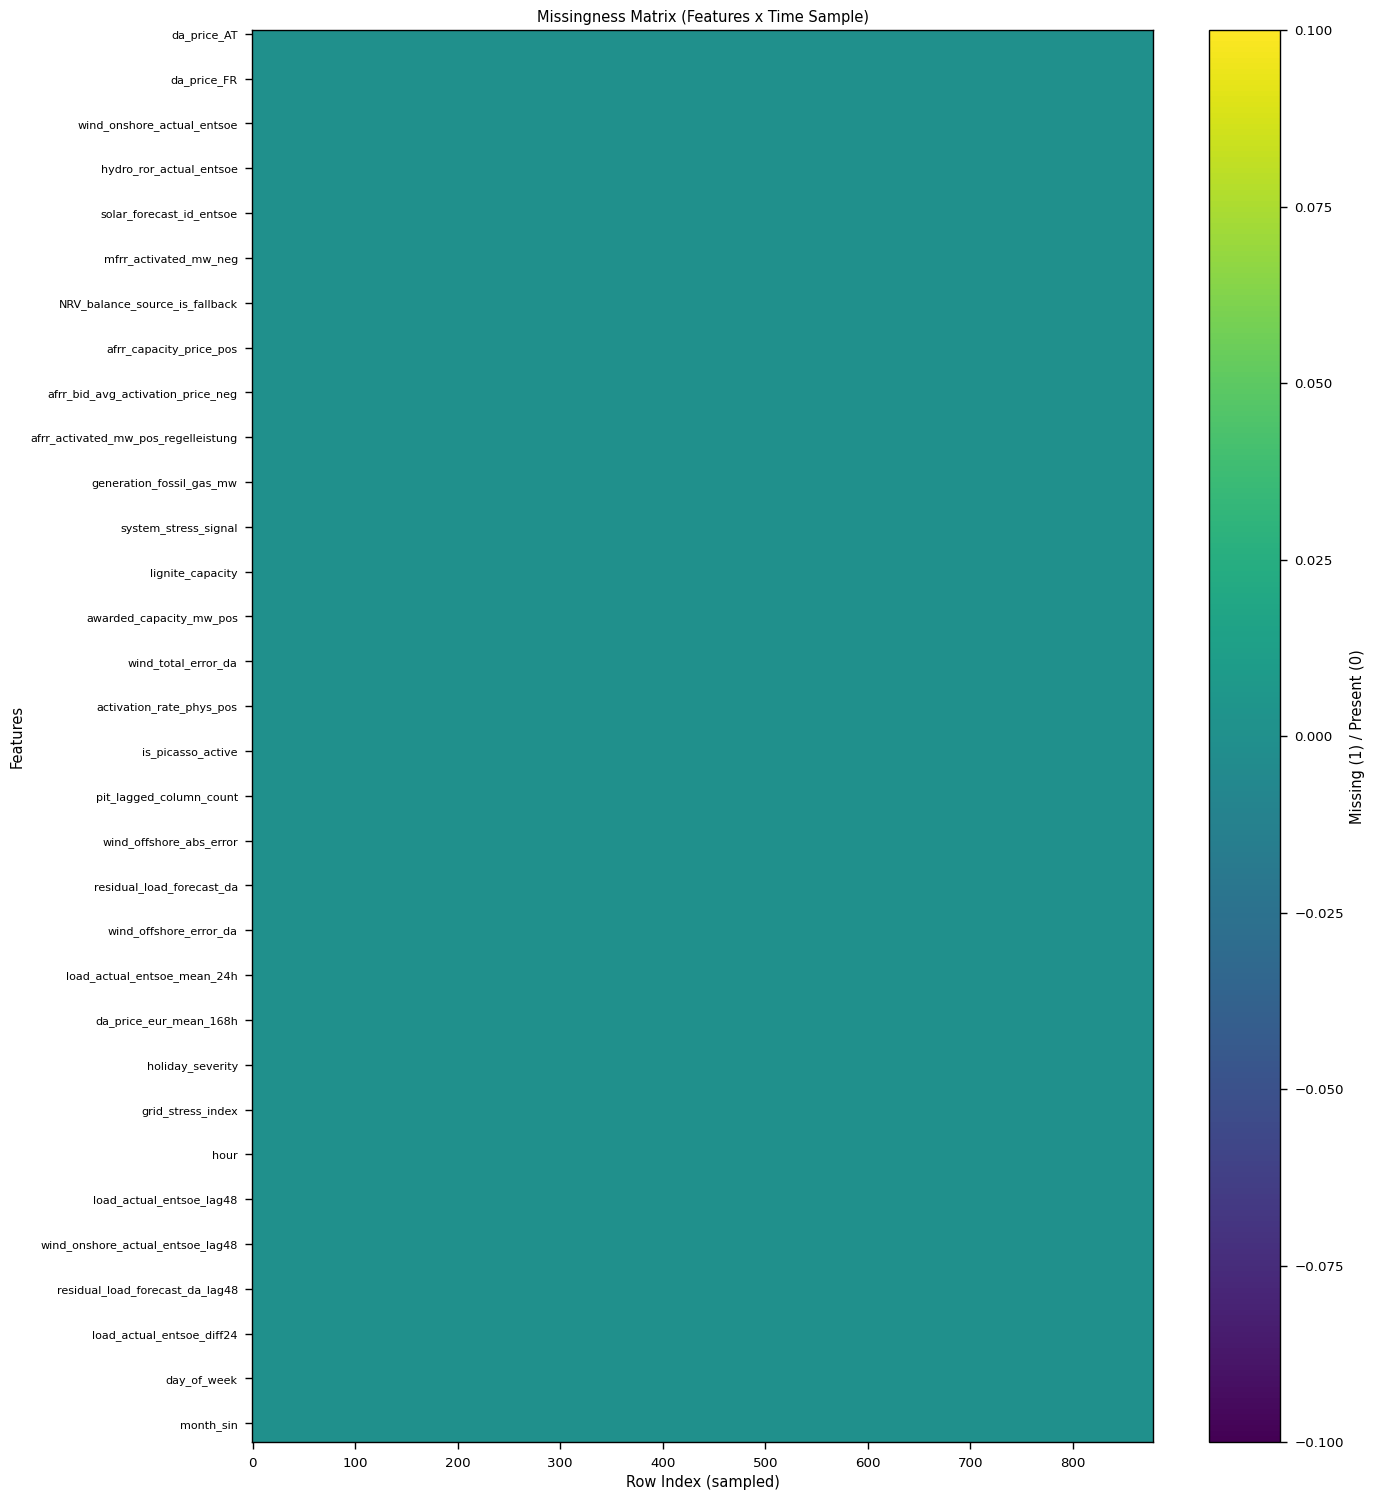

In [5]:
# Missingness matrix plot (sampled rows for readability)
if len(FEATURES) == 0:
    print('No feature columns available for missingness matrix.')
else:
    sample_n = min(len(pdf), 2500)
    sample = pdf[FEATURES].iloc[:sample_n]
    miss_bin = sample.isna().astype(int).T  # features x time

    fig, ax = plt.subplots(figsize=(14, max(6, len(FEATURES) * 0.08)))
    im = ax.imshow(miss_bin, aspect='auto', interpolation='nearest', cmap='viridis')
    ax.set_title('Missingness Matrix (Features x Time Sample)')
    ax.set_xlabel('Row Index (sampled)')
    ax.set_ylabel('Features')

    yticks = np.arange(0, len(FEATURES), max(1, len(FEATURES)//30))
    ax.set_yticks(yticks)
    ax.set_yticklabels([FEATURES[i] for i in yticks], fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Missing (1) / Present (0)')
    plt.tight_layout()
    plt.show()


## Multicollinearity Audit (Pearson)

We compute a Pearson matrix on numeric features and visualize correlation
structure via hierarchical clustering. High-correlation pairs (`|r| > 0.95`)
are flagged as redundancy candidates.


In [6]:
num_features = [c for c in FEATURES if pd.api.types.is_numeric_dtype(pdf[c])]
num_df = pdf[num_features].copy()

# Optional robust imputation only for correlation computation
corr_input = num_df.copy()
for c in corr_input.columns:
    if corr_input[c].isna().all():
        corr_input[c] = 0.0
corr_input = corr_input.fillna(corr_input.median(numeric_only=True))

corr = corr_input.corr(method='pearson')
print(f'Numeric feature count for correlation: {len(num_features)}')
print(f'Correlation matrix shape: {corr.shape}')


Numeric feature count for correlation: 187
Correlation matrix shape: (187, 187)


In [7]:
# Clustermap for correlation blocks (finite-only robust version)
corr_plot = corr.copy()
corr_plot = corr_plot.replace([np.inf, -np.inf], np.nan)

# Drop features with non-finite correlations (typically constant/all-null columns)
finite_cols = corr_plot.columns[corr_plot.notna().all(axis=0)]
corr_plot = corr_plot.loc[finite_cols, finite_cols]

if corr_plot.shape[0] >= 2:
    clust = sns.clustermap(
        corr_plot,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(16, 16),
        xticklabels=False,
        yticklabels=False,
    )
    clust.fig.suptitle('Feature Correlation Clustermap (Pearson, finite-only)', y=1.02)
    plt.show()
else:
    print('Not enough finite numeric features for clustermap after filtering.')


Not enough finite numeric features for clustermap after filtering.


In [8]:
# Highly correlated pairs and drop recommendation
threshold = 0.95
pairs = []
cols = corr.columns.tolist()

na_counts = pdf[cols].isna().sum()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iat[i, j]
        if pd.notna(r) and abs(r) > threshold:
            c1, c2 = cols[i], cols[j]
            # Recommendation: drop feature with more NAs
            drop = c1 if na_counts[c1] >= na_counts[c2] else c2
            keep = c2 if drop == c1 else c1
            pairs.append((c1, c2, r, int(na_counts[c1]), int(na_counts[c2]), drop, keep))

corr_pairs = pd.DataFrame(
    pairs,
    columns=['feature_a', 'feature_b', 'pearson_r', 'na_a', 'na_b', 'recommend_drop', 'recommend_keep']
).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)

print(f'Pairs with |r| > {threshold}: {len(corr_pairs)}')
display(corr_pairs.head(100))


Pairs with |r| > 0.95: 46


,feature_a,feature_b,pearson_r,na_a,na_b,recommend_drop,recommend_keep
23,afrr_bid_vwap_activation_price_pos,bid_signed_vwap_eur_mwh_pos,1.000000,0,0,afrr_bid_vwap_activation_price_pos,bid_signed_vwap_eur_mwh_pos
15,net_import_export_mw,picasso_flow_rate,1.000000,0,0,net_import_export_mw,picasso_flow_rate
35,activation_rate_phys_pos,afrr_activation_rate_pos,1.000000,0,0,activation_rate_phys_pos,afrr_activation_rate_pos
31,awarded_capacity_mw_neg,afrr_capacity_awarded_mw_neg,1.000000,0,0,awarded_capacity_mw_neg,afrr_capacity_awarded_mw_neg
30,awarded_capacity_mw_pos,afrr_capacity_awarded_mw_pos,1.000000,0,0,awarded_capacity_mw_pos,afrr_capacity_awarded_mw_pos
29,system_stress_signal,total_wind_solar_id_error,1.000000,0,0,system_stress_signal,total_wind_solar_id_error
27,bid_alloc_mw_pos,afrr_capacity_awarded_mw_pos,1.000000,0,0,bid_alloc_mw_pos,afrr_capacity_awarded_mw_pos
26,bid_alloc_mw_pos,awarded_capacity_mw_pos,1.000000,0,0,bid_alloc_mw_pos,awarded_capacity_mw_pos
25,bid_alloc_mw_neg,afrr_capacity_awarded_mw_neg,1.000000,0,0,bid_alloc_mw_neg,afrr_capacity_awarded_mw_neg
24,bid_alloc_mw_neg,awarded_capacity_mw_neg,1.000000,0,0,bid_alloc_mw_neg,awarded_capacity_mw_neg


## Variance Inflation Factor (VIF)

VIF is computed in manageable feature subgroups to keep runtime tractable.
A threshold of `VIF > 10` is used as a classical multicollinearity warning.


In [9]:
def compute_vif_for_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    X = df[cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    # Drop constant columns to avoid singular matrix behavior
    nunique = X.nunique(dropna=False)
    keep_cols = nunique[nunique > 1].index.tolist()
    dropped_const = sorted(set(cols) - set(keep_cols))
    X = X[keep_cols]

    out = []
    if X.shape[1] >= 2:
        vals = X.to_numpy(dtype=float)
        for i, c in enumerate(X.columns):
            vif = variance_inflation_factor(vals, i)
            out.append((c, float(vif)))
    vif_df = pd.DataFrame(out, columns=['feature', 'vif']).sort_values('vif', ascending=False)
    vif_df['dropped_constant'] = False

    if dropped_const:
        const_df = pd.DataFrame({'feature': dropped_const, 'vif': np.nan, 'dropped_constant': True})
        vif_df = pd.concat([vif_df, const_df], ignore_index=True)

    return vif_df


def compute_vif_in_chunks(df: pd.DataFrame, cols: list[str], chunk_size: int = 40) -> pd.DataFrame:
    reports = []
    for start in range(0, len(cols), chunk_size):
        sub = cols[start:start + chunk_size]
        if len(sub) < 2:
            continue
        sub_report = compute_vif_for_columns(df, sub)
        sub_report['chunk_start'] = start
        sub_report['chunk_end'] = start + len(sub) - 1
        reports.append(sub_report)
    if not reports:
        return pd.DataFrame(columns=['feature', 'vif', 'dropped_constant', 'chunk_start', 'chunk_end'])
    return pd.concat(reports, ignore_index=True)


In [10]:
vif_report = compute_vif_in_chunks(num_df, num_features, chunk_size=40)
high_vif = vif_report[(vif_report['vif'] > 10) & (~vif_report['dropped_constant'])].copy()

print('Top VIF entries:')
display(vif_report.sort_values('vif', ascending=False).head(40))
print(f'Features with VIF > 10: {len(high_vif)}')
display(high_vif.sort_values('vif', ascending=False))


Top VIF entries:


,feature,vif,dropped_constant,chunk_start,chunk_end
0,afrr_picasso_net_mw,inf,False,0,39
1,afrr_picasso_mw_neg,inf,False,0,39
92,wind_onshore_forecast_delta,inf,False,80,119
91,wind_onshore_error_id,inf,False,80,119
90,wind_forecast_update,inf,False,80,119
89,residual_load_calc,inf,False,80,119
88,wind_onshore_error_da,inf,False,80,119
40,bid_signed_vwap_eur_mwh_neg,inf,False,40,79
41,afrr_bid_vwap_activation_price_neg,inf,False,40,79
42,awarded_capacity_mw_pos,inf,False,40,79


Features with VIF > 10: 115


,feature,vif,dropped_constant,chunk_start,chunk_end
0,afrr_picasso_net_mw,inf,False,0,39
40,bid_signed_vwap_eur_mwh_neg,inf,False,40,79
42,awarded_capacity_mw_pos,inf,False,40,79
43,awarded_capacity_mw_neg,inf,False,40,79
44,bid_signed_vwap_eur_mwh_pos,inf,False,40,79
45,bid_alloc_mw_neg,inf,False,40,79
46,afrr_bid_vwap_activation_price_pos,inf,False,40,79
47,bid_alloc_mw_pos,inf,False,40,79
80,afrr_activation_rate_pos,inf,False,80,119
81,activation_rate_phys_pos,inf,False,80,119


## Target Interaction Audit

We analyze feature correlation against a primary target proxy for short-horizon
signal quality and leakage suspicion.

- **Dead features:** `|corr| < 0.01`
- **Leakage-suspicious:** `|corr| > 0.90` for non-price-like variables


In [11]:
# Primary target selection
candidate_targets = [
    'y_true_h1',
    'target_pos_h1',
    'y_true_pos',
]
primary_target = next((c for c in candidate_targets if c in pdf.columns), None)
if primary_target is None:
    raise KeyError(f'No primary target found. Tried: {candidate_targets}')

print('Primary target used:', primary_target)

num_feature_df = pdf[num_features].copy()
target_s = pd.to_numeric(pdf[primary_target], errors='coerce')

target_corr = num_feature_df.corrwith(target_s).rename('corr_to_target').to_frame()
target_corr['abs_corr'] = target_corr['corr_to_target'].abs()
target_corr = target_corr.sort_values('abs_corr', ascending=False)

dead_features = target_corr[target_corr['abs_corr'] < 0.01].copy()

price_like_tokens = ('price', 'y_true', 'y_train', 'target_', 'spread', 'vwap')
non_price = [c for c in target_corr.index if not any(tok in c.lower() for tok in price_like_tokens)]
leakage_suspects = target_corr.loc[non_price]
leakage_suspects = leakage_suspects[leakage_suspects['abs_corr'] > 0.90].copy()

print('Top feature-target correlations:')
display(target_corr.head(40))

print(f'Dead features (|corr| < 0.01): {len(dead_features)}')
display(dead_features)

print(f'Leakage suspects (non-price, |corr| > 0.90): {len(leakage_suspects)}')
display(leakage_suspects.sort_values('abs_corr', ascending=False))


Primary target used: target_pos_h1
Top feature-target correlations:


,corr_to_target,abs_corr
afrr_bid_vwap_activation_price_pos,0.792177,0.792177
bid_signed_vwap_eur_mwh_pos,0.792177,0.792177
afrr_vwap_pos,0.616232,0.616232
afrr_id_price_spread,0.614640,0.614640
relative_price_competitiveness,0.510922,0.510922
afrr_bid_vwap_activation_price_neg,-0.431769,0.431769
bid_signed_vwap_eur_mwh_neg,-0.431769,0.431769
afrr_vwap_neg,-0.359074,0.359074
scarcity_price_premium,0.271239,0.271239
price_volatility_short_term,0.260184,0.260184


Dead features (|corr| < 0.01): 9


,corr_to_target,abs_corr
wind_onshore_actual_entsoe_mean_168h,-0.009563,0.009563
NRV_balance,-0.007697,0.007697
mfrr_activated_mw_neg,-0.007363,0.007363
load_total_incl_pumping,-0.006718,0.006718
wind_offshore_error_da,-0.004838,0.004838
wind_offshore_mae_rolling_72h,0.003654,0.003654
afrr_picasso_net_mw,-0.001959,0.001959
afrr_marginal_activation_price_neg,-0.001888,0.001888
load_actual_entsoe_std_168h,0.000721,0.000721


Leakage suspects (non-price, |corr| > 0.90): 0


,corr_to_target,abs_corr


## Final Thesis Summary: Candidate Feature Pruning

`FEATURES_TO_DROP` is generated from three conservative criteria:

1. Missingness > 5%
2. Recommended drops from high-correlation pairs (`|r| > 0.95`)
3. VIF > 10

This list is a candidate set for model selection, not an automatic hard delete.
Final decisions should be re-validated with purged walk-forward CV.


In [12]:
drop_missing = set(high_missing.index.tolist())
drop_corr = set(corr_pairs['recommend_drop'].tolist()) if len(corr_pairs) else set()
drop_vif = set(high_vif['feature'].dropna().tolist()) if len(high_vif) else set()

FEATURES_TO_DROP = sorted(drop_missing | drop_corr | drop_vif)

summary = pd.DataFrame([
    ('missing_gt_5pct', len(drop_missing)),
    ('corr_abs_gt_0_95', len(drop_corr)),
    ('vif_gt_10', len(drop_vif)),
    ('union_features_to_drop', len(FEATURES_TO_DROP)),
], columns=['rule', 'count'])

display(summary)
print('FEATURES_TO_DROP (first 200 shown):')
print(FEATURES_TO_DROP[:200])

# Keep as explicit notebook variable for downstream usage
FEATURES_TO_DROP


,rule,count
0,missing_gt_5pct,0
1,corr_abs_gt_0_95,34
2,vif_gt_10,115
3,union_features_to_drop,121


FEATURES_TO_DROP (first 200 shown):
['TE_hour_regime_activation', 'activation_rate_ml_neg', 'activation_rate_ml_pos', 'activation_rate_phys_neg', 'activation_rate_phys_pos', 'afrr_activated_mw_neg', 'afrr_activated_mw_pos', 'afrr_activation_offered_mw_neg', 'afrr_activation_offered_mw_pos', 'afrr_activation_rate_neg', 'afrr_activation_rate_pos', 'afrr_bid_avg_activation_price_neg', 'afrr_bid_avg_activation_price_pos', 'afrr_bid_vwap_activation_price_neg', 'afrr_bid_vwap_activation_price_pos', 'afrr_capacity_awarded_mw_neg', 'afrr_capacity_awarded_mw_pos', 'afrr_capacity_offered_mw_neg', 'afrr_capacity_offered_mw_pos', 'afrr_id_price_spread', 'afrr_marginal_activation_price_neg', 'afrr_marginal_activation_price_pos', 'afrr_picasso_mw_neg', 'afrr_picasso_mw_pos', 'afrr_picasso_net_mw', 'afrr_vwap_neg', 'afrr_vwap_pos', 'awarded_capacity_mw_neg', 'awarded_capacity_mw_pos', 'bid_alloc_mw_neg', 'bid_alloc_mw_pos', 'bid_signed_vwap_eur_mwh_neg', 'bid_signed_vwap_eur_mwh_pos', 'biomass_actual

['TE_hour_regime_activation',
 'activation_rate_ml_neg',
 'activation_rate_ml_pos',
 'activation_rate_phys_neg',
 'activation_rate_phys_pos',
 'afrr_activated_mw_neg',
 'afrr_activated_mw_pos',
 'afrr_activation_offered_mw_neg',
 'afrr_activation_offered_mw_pos',
 'afrr_activation_rate_neg',
 'afrr_activation_rate_pos',
 'afrr_bid_avg_activation_price_neg',
 'afrr_bid_avg_activation_price_pos',
 'afrr_bid_vwap_activation_price_neg',
 'afrr_bid_vwap_activation_price_pos',
 'afrr_capacity_awarded_mw_neg',
 'afrr_capacity_awarded_mw_pos',
 'afrr_capacity_offered_mw_neg',
 'afrr_capacity_offered_mw_pos',
 'afrr_id_price_spread',
 'afrr_marginal_activation_price_neg',
 'afrr_marginal_activation_price_pos',
 'afrr_picasso_mw_neg',
 'afrr_picasso_mw_pos',
 'afrr_picasso_net_mw',
 'afrr_vwap_neg',
 'afrr_vwap_pos',
 'awarded_capacity_mw_neg',
 'awarded_capacity_mw_pos',
 'bid_alloc_mw_neg',
 'bid_alloc_mw_pos',
 'bid_signed_vwap_eur_mwh_neg',
 'bid_signed_vwap_eur_mwh_pos',
 'biomass_actual_en

## Structured Multicollinearity Analysis (Thesis Extension)

This section implements a **hybrid pruning framework**:
1. Group-wise VIF screening (numerically stable, domain-specific blocks)
2. Pairwise Pearson audit (|r| > 0.95)
3. Economic review matrix for final keep/drop/merge decisions

The objective is not purely statistical deletion, but **causal and economic model design** for the aFRR setting.


### Why VIF and Why Group-Wise?

**Variance Inflation Factor (VIF)** measures how much the variance of an
estimated regression coefficient is increased because of collinearity.
For feature $x_j$:

\[
\mathrm{VIF}_j = \frac{1}{1 - R_j^2}
\]

where $R_j^2$ is from regressing $x_j$ on all other features in the set.

Computing VIF across all 300+ columns can be numerically unstable and hard to
interpret. Therefore, we apply VIF within **market-logical clusters**
(prices, renewables, load, aFRR market, engineered stats), which improves both
stability and domain specificity.


In [13]:
# --- Cluster definitions + robust grouped VIF ---
from typing import Dict, List


def _cluster_cols(all_cols: list[str]) -> Dict[str, List[str]]:
    # 1) Price Cluster: DA (DE + abroad) + intraday
    price_cluster = [
        c for c in all_cols
        if c.startswith('da_price_') or c == 'price_intraday_eur'
    ]

    # 2) Renewables Cluster: wind/solar actuals, forecasts, errors
    renewables_cluster = [
        c for c in all_cols
        if any(k in c for k in ['wind_', 'solar_'])
    ]

    # 3) Load Cluster: load + residual family
    load_cluster = [
        c for c in all_cols
        if ('load_' in c) or ('residual_' in c)
    ]

    # 4) aFRR Market Cluster: Picasso/VWAP/Bids/aFRR/mFRR core
    afrr_cluster = [
        c for c in all_cols
        if (
            c.startswith('afrr_')
            or c.startswith('mfrr_')
            or c.startswith('bid_')
            or 'vwap' in c
            or 'picasso' in c
            or 'rebap' in c.lower()
            or 'nrv_' in c.lower()
        )
    ]

    # 5) Stats Cluster: rolling moments + explicit lags + diffs + ewma
    stats_cluster = [
        c for c in all_cols
        if (
            '_mean_' in c
            or '_std_' in c
            or '_lag' in c
            or c.endswith('diff1')
            or c.endswith('diff24')
            or 'ewma' in c
            or 'zscore' in c
        )
    ]

    return {
        'Price Cluster': sorted(set(price_cluster)),
        'Renewables Cluster': sorted(set(renewables_cluster)),
        'Load Cluster': sorted(set(load_cluster)),
        'aFRR Market Cluster': sorted(set(afrr_cluster)),
        'Stats Cluster': sorted(set(stats_cluster)),
    }


def compute_group_vif(df: pd.DataFrame, cols: list[str], group_name: str) -> pd.DataFrame:
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        return pd.DataFrame(columns=['group', 'feature', 'vif'])

    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors='coerce')

    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
    if X.shape[0] < 30:
        return pd.DataFrame(columns=['group', 'feature', 'vif'])

    keep = [c for c in X.columns if X[c].nunique(dropna=True) > 1]
    X = X[keep]
    if X.shape[1] < 2:
        return pd.DataFrame(columns=['group', 'feature', 'vif'])

    X = (X - X.mean()) / X.std(ddof=0)
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
    if X.shape[0] < 30 or X.shape[1] < 2:
        return pd.DataFrame(columns=['group', 'feature', 'vif'])

    rows = []
    for i, c in enumerate(X.columns):
        try:
            v = variance_inflation_factor(X.values, i)
            rows.append({'group': group_name, 'feature': c, 'vif': float(v)})
        except Exception:
            rows.append({'group': group_name, 'feature': c, 'vif': np.inf})

    out = pd.DataFrame(rows).sort_values('vif', ascending=False)
    return out


all_numeric_cols = [c for c in FEATURES if c in pdf.columns and pd.api.types.is_numeric_dtype(pdf[c])]
clusters = _cluster_cols(all_numeric_cols)

vif_frames = []
for g, cols in clusters.items():
    rep = compute_group_vif(pdf, cols, g)
    if not rep.empty:
        vif_frames.append(rep)

if vif_frames:
    vif_group_report = pd.concat(vif_frames, ignore_index=True).sort_values(['group', 'vif'], ascending=[True, False])
else:
    vif_group_report = pd.DataFrame(columns=['group', 'feature', 'vif'])

print('Block-VIF summary (top rows):')
display(vif_group_report.head(40))

vif_critical = vif_group_report[vif_group_report['vif'] > 10].copy()
print(f'Features with VIF > 10: {len(vif_critical)}')
display(vif_critical.head(80))


Block-VIF summary (top rows):


,group,feature,vif
61,Load Cluster,residual_load_calc,inf
62,Load Cluster,load_actual_entsoe_lag24,inf
63,Load Cluster,load_actual_entsoe,inf
64,Load Cluster,residual_load_forecast_da,inf
65,Load Cluster,residual_forecast_error,inf
66,Load Cluster,load_actual_entsoe_diff24,inf
67,Load Cluster,load_total_incl_pumping_lag168,255.161586
68,Load Cluster,load_total_incl_pumping_lag48,253.908696
69,Load Cluster,load_actual_entsoe_lag48,241.528694
70,Load Cluster,load_total_incl_pumping,232.691574


Features with VIF > 10: 100


,group,feature,vif
61,Load Cluster,residual_load_calc,inf
62,Load Cluster,load_actual_entsoe_lag24,inf
63,Load Cluster,load_actual_entsoe,inf
64,Load Cluster,residual_load_forecast_da,inf
65,Load Cluster,residual_forecast_error,inf
66,Load Cluster,load_actual_entsoe_diff24,inf
67,Load Cluster,load_total_incl_pumping_lag168,2.551616e+02
68,Load Cluster,load_total_incl_pumping_lag48,2.539087e+02
69,Load Cluster,load_actual_entsoe_lag48,2.415287e+02
70,Load Cluster,load_total_incl_pumping,2.326916e+02


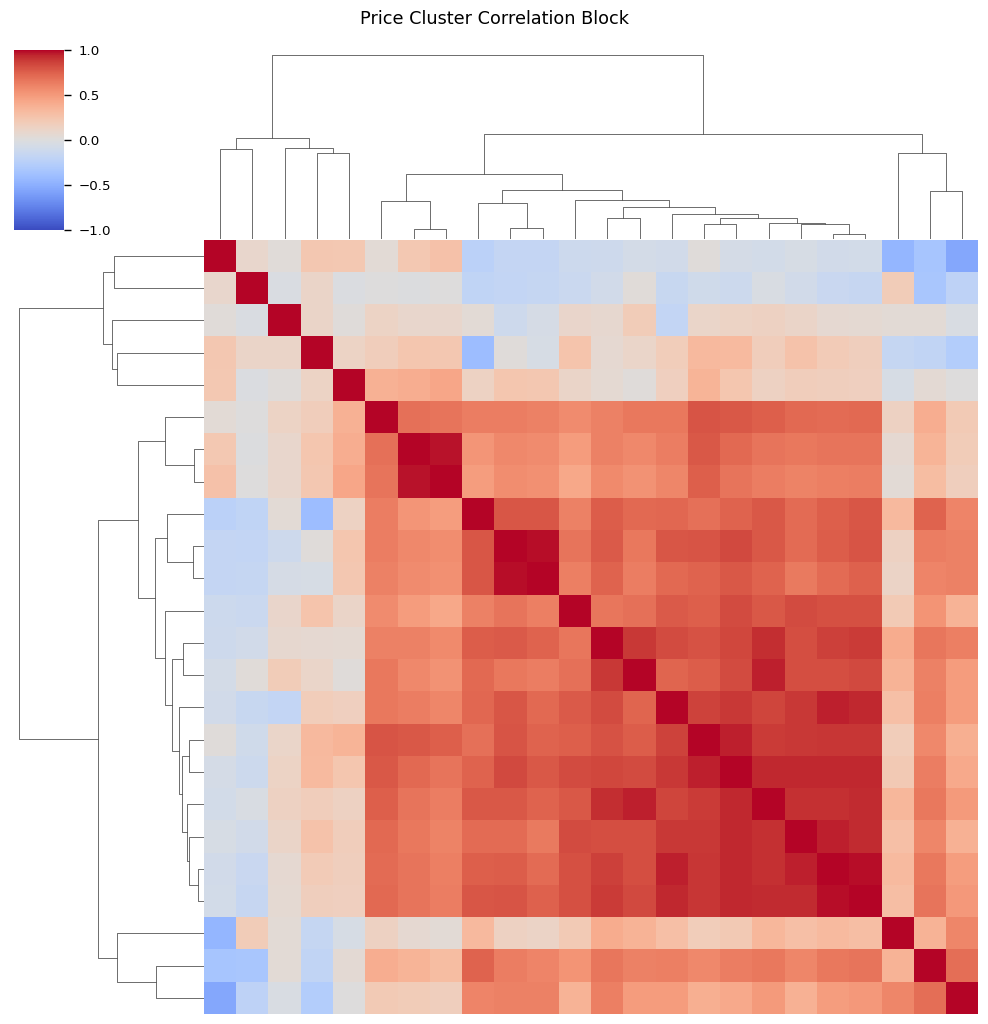

Renewables Cluster Correlation Block: skipped (insufficient finite correlation matrix).


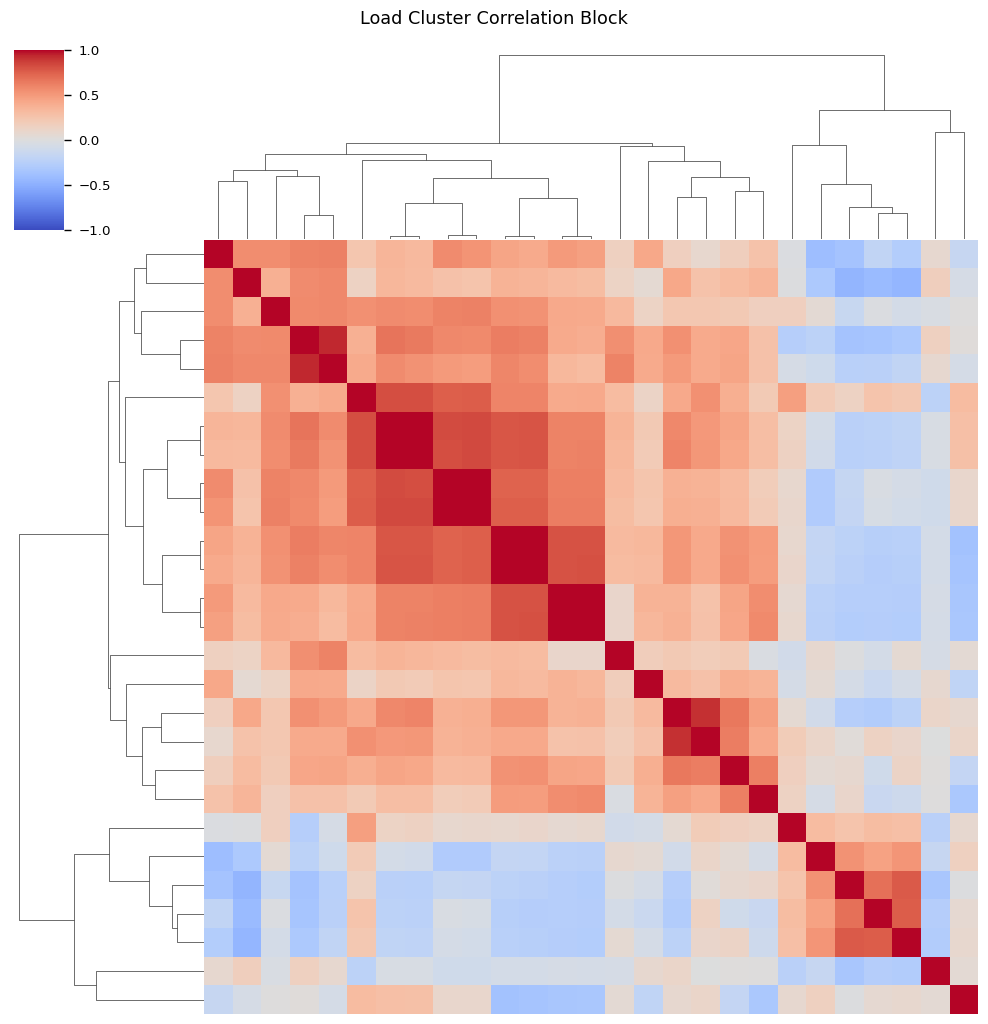

aFRR Market Cluster Correlation Block: skipped (insufficient finite correlation matrix).
Stats Cluster Correlation Block: skipped (insufficient finite correlation matrix).
High-correlation pairs (|r| > 0.95): 46


,feature_1,feature_2,corr,abs_corr
23,afrr_capacity_awarded_mw_pos,bid_alloc_mw_pos,1.000000,1.000000
38,picasso_flow_rate,net_import_export_mw,1.000000,1.000000
32,afrr_activation_rate_neg,activation_rate_phys_neg,1.000000,1.000000
31,afrr_activation_rate_pos,activation_rate_ml_pos,1.000000,1.000000
30,afrr_activation_rate_pos,activation_rate_phys_pos,1.000000,1.000000
29,activation_rate_ml_neg,activation_rate_phys_neg,1.000000,1.000000
28,activation_rate_ml_pos,activation_rate_phys_pos,1.000000,1.000000
27,afrr_capacity_awarded_mw_neg,awarded_capacity_mw_neg,1.000000,1.000000
26,afrr_capacity_awarded_mw_neg,bid_alloc_mw_neg,1.000000,1.000000
35,wind_onshore_forecast_delta,wind_forecast_update,1.000000,1.000000


In [14]:
# --- Correlation blocks + pairwise audit (|r| > 0.95) ---

def _cluster_corr_plot(df: pd.DataFrame, cols: list[str], title: str) -> None:
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        print(f'{title}: skipped (not enough columns).')
        return

    corr_local = df[cols].corr(numeric_only=True)
    corr_local = corr_local.replace([np.inf, -np.inf], np.nan)
    finite_cols = corr_local.columns[corr_local.notna().all(axis=0)]
    corr_local = corr_local.loc[finite_cols, finite_cols]

    if corr_local.shape[0] < 2:
        print(f'{title}: skipped (insufficient finite correlation matrix).')
        return

    g = sns.clustermap(
        corr_local,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(10, 10),
        xticklabels=False,
        yticklabels=False,
    )
    g.fig.suptitle(title, y=1.02)
    plt.show()


for group_name, cols in clusters.items():
    _cluster_corr_plot(pdf, cols, f'{group_name} Correlation Block')

num_df_all = pdf[all_numeric_cols].copy()
for c in num_df_all.columns:
    num_df_all[c] = pd.to_numeric(num_df_all[c], errors='coerce')

corr_all = num_df_all.corr(numeric_only=True)
upper = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))

pairs = []
for c1 in upper.columns:
    s = upper[c1].dropna()
    s = s[s.abs() > 0.95]
    for c2, r in s.items():
        pairs.append((c1, c2, float(r), abs(float(r))))

pairwise_high_corr = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f'High-correlation pairs (|r| > 0.95): {len(pairwise_high_corr)}')
display(pairwise_high_corr.head(80))


In [15]:
# --- Decision matrix: combine VIF + pairwise criteria ---

if 'y_true_pos_h1' in pdf.columns:
    primary_target = 'y_true_pos_h1'
elif 'target_pos_h1' in pdf.columns:
    primary_target = 'target_pos_h1'
elif 'y_true_pos' in pdf.columns:
    primary_target = 'y_true_pos'
else:
    primary_target = None

if primary_target is None:
    print('No primary target found for pairwise drop heuristic.')

feat_target_corr = {}
if primary_target is not None:
    y = pd.to_numeric(pdf[primary_target], errors='coerce')
    for c in all_numeric_cols:
        x = pd.to_numeric(pdf[c], errors='coerce')
        feat_target_corr[c] = x.corr(y)

pair_decisions = []
if len(pairwise_high_corr) > 0 and primary_target is not None:
    for _, r in pairwise_high_corr.iterrows():
        f1, f2 = r['feature_1'], r['feature_2']
        c1 = abs(feat_target_corr.get(f1, np.nan))
        c2 = abs(feat_target_corr.get(f2, np.nan))

        if np.isnan(c1) and np.isnan(c2):
            drop_candidate = f2
        elif np.isnan(c1):
            drop_candidate = f1
        elif np.isnan(c2):
            drop_candidate = f2
        else:
            drop_candidate = f1 if c1 < c2 else f2

        pair_decisions.append({
            'feature': drop_candidate,
            'driver': f'pairwise |r|={r["abs_corr"]:.3f}',
            'score': float(r['abs_corr']),
            'stat_reco': 'Drop or Merge',
            'market_logic_note': 'Highly collinear pair; keep economically superior proxy.',
        })

vif_decisions = []
for _, r in vif_critical.iterrows():
    vif_decisions.append({
        'feature': r['feature'],
        'driver': f'VIF in {r["group"]}',
        'score': float(r['vif']),
        'stat_reco': 'Drop or Merge',
        'market_logic_note': 'Check if feature is derivative of same base signal.',
    })

Feature_Decision_Matrix = pd.DataFrame(vif_decisions + pair_decisions)
if not Feature_Decision_Matrix.empty:
    Feature_Decision_Matrix = (
        Feature_Decision_Matrix
        .sort_values(['score', 'feature'], ascending=[False, True])
        .drop_duplicates(subset=['feature'], keep='first')
        .reset_index(drop=True)
    )

print('Feature_Decision_Matrix (critical features):')
display(Feature_Decision_Matrix.head(120))


Feature_Decision_Matrix (critical features):


,feature,driver,score,stat_reco,market_logic_note
0,afrr_activated_mw_neg,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
1,afrr_activated_mw_neg_regelleistung,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
2,afrr_activated_mw_pos,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
3,afrr_activated_mw_pos_regelleistung,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
4,afrr_bid_vwap_activation_price_neg,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
5,afrr_bid_vwap_activation_price_pos,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
6,afrr_capacity_awarded_mw_neg,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
7,afrr_capacity_awarded_mw_pos,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
8,afrr_picasso_mw_neg,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...
9,afrr_picasso_mw_pos,VIF in aFRR Market Cluster,inf,Drop or Merge,Check if feature is derivative of same base si...


In [16]:
# --- Aggregation prototypes for pruning/merging ---

def add_neighboring_price_index(df: pd.DataFrame, weights: dict[str, float] | None = None) -> pd.DataFrame:
    # Create weighted DA neighboring price index (excluding DE)
    out = df.copy()
    da_neighbors = [
        c for c in out.columns
        if c.startswith('da_price_') and c not in {'da_price_eur', 'da_price_d_eur_mwh'}
    ]
    if not da_neighbors:
        return out

    if weights is None:
        w = pd.Series(1.0, index=da_neighbors)
    else:
        w = pd.Series({c: float(weights.get(c, 0.0)) for c in da_neighbors})
        if float(w.sum()) <= 0:
            w = pd.Series(1.0, index=da_neighbors)

    w = w / w.sum()
    mat = out[da_neighbors].apply(pd.to_numeric, errors='coerce')
    out['neighboring_da_price_index'] = mat.mul(w, axis=1).sum(axis=1, min_count=1)
    return out


def add_wind_uncertainty_index(df: pd.DataFrame) -> pd.DataFrame:
    # Aggregate wind-error family into one uncertainty index
    out = df.copy()
    wind_err_cols = [
        c for c in out.columns
        if ('wind' in c and ('error' in c or 'abs_error' in c or 'forecast_delta' in c))
    ]
    if not wind_err_cols:
        return out

    mat = out[wind_err_cols].apply(pd.to_numeric, errors='coerce').abs()
    out['wind_uncertainty_index'] = mat.mean(axis=1, skipna=True)
    return out


pdf_agg_demo = add_neighboring_price_index(pdf)
pdf_agg_demo = add_wind_uncertainty_index(pdf_agg_demo)

print('Aggregation demo columns created:')
for c in ['neighboring_da_price_index', 'wind_uncertainty_index']:
    print(f'- {c}:', c in pdf_agg_demo.columns)


Aggregation demo columns created:
- neighboring_da_price_index: True
- wind_uncertainty_index: True


### Interpretation Workflow for Thesis Decisions

Use `Feature_Decision_Matrix` as a **candidate list**, not as automatic deletion.
Final decisions should combine:
- statistical trigger (VIF/correlation),
- causal validity (PiT latency),
- and economic meaning in the German/european aFRR context.

Recommended rule:
1. Drop exact duplicates and mechanically-derived twins.
2. Merge regional twins into indices when economic interpretation is preserved.
3. Keep one canonical feature per economic mechanism (price, imbalance, uncertainty, outage, regime).
